In [1]:
import copy
import io
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from torch.ao.quantization import (
    DeQuantStub,
    QuantStub,
    convert,
    fuse_modules,
    get_default_qat_qconfig,
    prepare_qat,
    quantize_dynamic,
)

# Optional torchao INT4 branch (best-effort)
TORCHAO_AVAILABLE = False
torchao_import_error = None
try:
    from torchao.quantization import quantize_, Int4WeightOnlyConfig
    TORCHAO_AVAILABLE = True
except Exception as e:
    torchao_import_error = str(e)
    warnings.warn(f"torchao INT4 branch unavailable: {e}")

W0322 12:34:10.138000 32436 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
SEED = 42
DATASET_NAME = "compas"  # "compas" or "german"
BATCH_SIZE = 64
BASE_EPOCHS = 25
QAT_FINETUNE_EPOCHS = 10
LR = 1e-3
REC_N_SAMPLES = 80
DECISION_THRESHOLD = 0.5

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Keep the experiment on CPU for quantization compatibility and reproducibility.
device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
def load_preprocess_dataset(dataset_name: str):
    if dataset_name.lower() == "compas":
        df = pd.read_csv("data/compas_carla.csv")
        target_col = "score"
    elif dataset_name.lower() == "german":
        df = pd.read_csv("data/german.csv")
        target_col = "credit_risk"
    else:
        raise ValueError("dataset_name must be 'compas' or 'german'.")

    y = df[target_col].astype(int).copy()
    X = df.drop(columns=[target_col]).copy()

    num_cols = X.select_dtypes(include=[np.number]).columns
    cat_cols = X.select_dtypes(include=["object", "category"]).columns

    scaler = StandardScaler()
    if len(num_cols) > 0:
        X[num_cols] = scaler.fit_transform(X[num_cols])

    X = pd.get_dummies(X, columns=cat_cols, dtype=float)
    X = X.astype(np.float32)

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.20, random_state=SEED, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.20,
        random_state=SEED,
        stratify=y_train_full,
    )

    data = {
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "feature_names": list(X.columns),
        "feature_min": X_train.min(axis=0).to_numpy(dtype=np.float32),
        "feature_max": X_train.max(axis=0).to_numpy(dtype=np.float32),
    }
    return data

data = load_preprocess_dataset(DATASET_NAME)
for k in ["X_train", "X_val", "X_test"]:
    print(f"{k}: {data[k].shape}")

X_train: (3949, 10)
X_val: (988, 10)
X_test: (1235, 10)


In [4]:
class MLPBinary(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(128, 128, 64)):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(hidden_dims[2], 1)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        return self.fc4(x).squeeze(-1)

    def predict_proba_tensor(self, x: torch.Tensor) -> torch.Tensor:
        probs_1 = torch.sigmoid(self.forward(x))
        probs_0 = 1.0 - probs_1
        return torch.stack([probs_0, probs_1], dim=1)

    def predict_proba(self, X):
        if isinstance(X, np.ndarray):
            xt = torch.tensor(X, dtype=torch.float32, device=device)
        else:
            xt = torch.tensor(np.asarray(X), dtype=torch.float32, device=device)
        self.eval()
        with torch.no_grad():
            out = self.predict_proba_tensor(xt).cpu().numpy()
        return out


class QuantizableMLPBinary(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(128, 128, 64)):
        super().__init__()
        self.quant = QuantStub()
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(hidden_dims[2], 1)
        self.dequant = DeQuantStub()

    def fuse_model(self):
        fuse_modules(self, [["fc1", "relu1"], ["fc2", "relu2"], ["fc3", "relu3"]], inplace=True)

    def forward(self, x):
        x = self.quant(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.fc4(x)
        x = self.dequant(x)
        return x.squeeze(-1)

    def predict_proba_tensor(self, x: torch.Tensor) -> torch.Tensor:
        probs_1 = torch.sigmoid(self.forward(x))
        probs_0 = 1.0 - probs_1
        return torch.stack([probs_0, probs_1], dim=1)

In [5]:
@dataclass
class Metrics:
    loss: float
    accuracy: float
    auroc: float


def evaluate_model(model, X_tensor, y_tensor, criterion):
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)
        loss = criterion(logits, y_tensor).item()
        probs = torch.sigmoid(logits).cpu().numpy()
        y_true = y_tensor.cpu().numpy()
        y_pred = (probs >= DECISION_THRESHOLD).astype(np.int32)
        acc = accuracy_score(y_true, y_pred)
        try:
            auc = roc_auc_score(y_true, probs)
        except ValueError:
            auc = float("nan")
    return Metrics(loss=loss, accuracy=acc, auroc=auc)


def train_model(model, train_loader, X_val, y_val, epochs=20, lr=1e-3):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
        if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
            m = evaluate_model(model, X_val, y_val, criterion)
            print(
                f"Epoch {epoch+1:>2}/{epochs} | val_loss={m.loss:.4f} "
                f"| val_acc={100*m.accuracy:.2f}% | val_auc={m.auroc:.4f}"
            )
    return model


def model_size_kb(model):
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    return len(buffer.getvalue()) / 1024.0

In [6]:
X_train_tensor = torch.tensor(data["X_train"].to_numpy(), dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(data["y_train"].to_numpy(), dtype=torch.float32, device=device)
X_val_tensor = torch.tensor(data["X_val"].to_numpy(), dtype=torch.float32, device=device)
y_val_tensor = torch.tensor(data["y_val"].to_numpy(), dtype=torch.float32, device=device)
X_test_tensor = torch.tensor(data["X_test"].to_numpy(), dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(data["y_test"].to_numpy(), dtype=torch.float32, device=device)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)

input_dim = X_train_tensor.shape[1]
print(f"Input dimension: {input_dim}")

base_model = MLPBinary(input_dim=input_dim).to(device)
base_model = train_model(base_model, train_loader, X_val_tensor, y_val_tensor, epochs=BASE_EPOCHS, lr=LR)

criterion_eval = nn.BCEWithLogitsLoss()
base_metrics = evaluate_model(base_model, X_test_tensor, y_test_tensor, criterion_eval)
print(
    f"FP32 Base | loss={base_metrics.loss:.4f} "
    f"| acc={100*base_metrics.accuracy:.2f}% | auc={base_metrics.auroc:.4f}"
)

Input dimension: 10
Epoch  5/25 | val_loss=0.3434 | val_acc=84.62% | val_auc=0.8546
Epoch 10/25 | val_loss=0.3425 | val_acc=84.62% | val_auc=0.8575
Epoch 15/25 | val_loss=0.3403 | val_acc=84.51% | val_auc=0.8571
Epoch 20/25 | val_loss=0.3380 | val_acc=84.31% | val_auc=0.8607
Epoch 25/25 | val_loss=0.3398 | val_acc=83.81% | val_auc=0.8596
FP32 Base | loss=0.3645 | acc=83.16% | auc=0.8292


In [7]:
# INT8 PTQ (dynamic quantization: weight INT8 for nn.Linear)
ptq_source_model = copy.deepcopy(base_model).cpu().eval()
ptq_int8_model = quantize_dynamic(
    ptq_source_model,
    {nn.Linear},
    dtype=torch.qint8,
 )

ptq_metrics = evaluate_model(ptq_int8_model, X_test_tensor.cpu(), y_test_tensor.cpu(), criterion_eval)
print(
    f"INT8 PTQ | loss={ptq_metrics.loss:.4f} "
    f"| acc={100*ptq_metrics.accuracy:.2f}% | auc={ptq_metrics.auroc:.4f}"
)

INT8 PTQ | loss=0.3643 | acc=83.48% | auc=0.8297


C:\Users\hashi\AppData\Local\Temp\ipykernel_32436\4062420941.py:3: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  ptq_int8_model = quantize_dynamic(


In [8]:
# INT8 QAT (eager mode)
qat_float_model = QuantizableMLPBinary(input_dim=input_dim).cpu()
qat_float_model.load_state_dict(copy.deepcopy(base_model).cpu().state_dict(), strict=True)
qat_float_model.fuse_model()
qat_float_model.qconfig = get_default_qat_qconfig("fbgemm")
prepare_qat(qat_float_model, inplace=True)

qat_optimizer = optim.Adam(qat_float_model.parameters(), lr=LR * 0.5)
qat_criterion = nn.BCEWithLogitsLoss()
qat_float_model.train()

for epoch in range(QAT_FINETUNE_EPOCHS):
    for xb, yb in train_loader:
        xb = xb.cpu()
        yb = yb.cpu()
        qat_optimizer.zero_grad()
        logits = qat_float_model(xb)
        loss = qat_criterion(logits, yb)
        loss.backward()
        qat_optimizer.step()
    if (epoch + 1) % 5 == 0 or epoch == QAT_FINETUNE_EPOCHS - 1:
        m = evaluate_model(qat_float_model, X_val_tensor.cpu(), y_val_tensor.cpu(), qat_criterion)
        print(
            f"QAT finetune {epoch+1:>2}/{QAT_FINETUNE_EPOCHS} "
            f"| val_loss={m.loss:.4f} | val_acc={100*m.accuracy:.2f}%"
        )

qat_float_model.eval()
qat_int8_model = copy.deepcopy(qat_float_model)
convert(qat_int8_model, inplace=True)

qat_metrics = evaluate_model(qat_int8_model, X_test_tensor.cpu(), y_test_tensor.cpu(), criterion_eval)
print(
    f"INT8 QAT | loss={qat_metrics.loss:.4f} "
    f"| acc={100*qat_metrics.accuracy:.2f}% | auc={qat_metrics.auroc:.4f}"
)

C:\Users\hashi\AppData\Local\Temp\ipykernel_32436\1296777381.py:6: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepare_qat(qat_float_model, inplace=True)
c:\Users\hashi\anaconda3\envs\657project\lib\site-packages\torch\ao\quantization\observer.py:534: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range wi

QAT finetune  5/10 | val_loss=0.3403 | val_acc=84.11%
QAT finetune 10/10 | val_loss=0.3418 | val_acc=84.41%
INT8 QAT | loss=0.3708 | acc=82.91% | auc=0.8279


C:\Users\hashi\AppData\Local\Temp\ipykernel_32436\1296777381.py:30: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  convert(qat_int8_model, inplace=True)


In [9]:
# Optional INT4 branch (best-effort, non-blocking)
int4_model = None
int4_status = "skipped"
int4_error = None

if TORCHAO_AVAILABLE:
    try:
        int4_model = copy.deepcopy(base_model).cpu().eval()
        quantize_(int4_model, Int4WeightOnlyConfig(group_size=32))
        int4_status = "ok"
        print("INT4 PTQ branch completed.")
    except Exception as e:
        int4_error = str(e)
        int4_status = "failed"
        print(f"INT4 branch failed: {e}")
else:
    print(f"INT4 branch unavailable: {torchao_import_error}")

INT4 branch failed: Requires mslk >= 1.0.0


In [10]:
results_models = [
    {
        "model": "FP32 base",
        "test_acc": base_metrics.accuracy,
        "test_auc": base_metrics.auroc,
        "size_kb": model_size_kb(base_model.cpu()),
    },
    {
        "model": "INT8 PTQ",
        "test_acc": ptq_metrics.accuracy,
        "test_auc": ptq_metrics.auroc,
        "size_kb": model_size_kb(ptq_int8_model),
    },
    {
        "model": "INT8 QAT",
        "test_acc": qat_metrics.accuracy,
        "test_auc": qat_metrics.auroc,
        "size_kb": model_size_kb(qat_int8_model),
    },
]

if int4_model is not None and int4_status == "ok":
    int4_metrics = evaluate_model(int4_model, X_test_tensor.cpu(), y_test_tensor.cpu(), criterion_eval)
    results_models.append(
        {
            "model": "INT4 PTQ (optional)",
            "test_acc": int4_metrics.accuracy,
            "test_auc": int4_metrics.auroc,
            "size_kb": model_size_kb(int4_model),
        }
    )

model_table = pd.DataFrame(results_models)
model_table["acc_delta_vs_base"] = model_table["test_acc"] - model_table.loc[0, "test_acc"]
model_table["size_reduction_vs_base"] = 1.0 - (model_table["size_kb"] / model_table.loc[0, "size_kb"])
model_table

,model,test_acc,test_auc,size_kb,acc_delta_vs_base,size_reduction_vs_base
0,FP32 base,0.831579,0.829193,105.575195,0.000000,0.000000
1,INT8 PTQ,0.834818,0.829662,32.299805,0.003239,0.694059
2,INT8 QAT,0.829150,0.827867,39.708008,-0.002429,0.623889


In [11]:
class NotebookPROBE:
    def __init__(
        self,
        lr=0.03,
        lambda_param=0.02,
        n_iter=1000,
        target_prob=0.55,
        invalidation_target=0.35,
        noise_variance=0.01,
        n_noise_samples=32,
    ):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iter = n_iter
        self.target_prob = target_prob
        self.invalidation_target = invalidation_target
        self.noise_variance = noise_variance
        self.n_noise_samples = n_noise_samples

    @staticmethod
    def _predict_prob_1(model, x_tensor):
        logits = model(x_tensor)
        return torch.sigmoid(logits)

    def _invalidation_rate_mc(self, model, x_tensor):
        eps = torch.randn(
            self.n_noise_samples, x_tensor.shape[1], dtype=x_tensor.dtype, device=x_tensor.device
        ) * np.sqrt(self.noise_variance)
        noisy = x_tensor.repeat(self.n_noise_samples, 1) + eps
        probs = self._predict_prob_1(model, noisy)
        return (probs < DECISION_THRESHOLD).float().mean()

    def get_recourse(self, model, x_np, feature_min, feature_max):
        model.eval()
        x0 = torch.tensor(x_np, dtype=torch.float32, device=device).reshape(1, -1)
        xmin = torch.tensor(feature_min, dtype=torch.float32, device=device).reshape(1, -1)
        xmax = torch.tensor(feature_max, dtype=torch.float32, device=device).reshape(1, -1)

        x_cf = x0.clone().detach().requires_grad_(True)
        optimizer = optim.Adam([x_cf], lr=self.lr)
        target = torch.ones(1, dtype=torch.float32, device=device)

        best = None
        best_cost = float("inf")

        for _ in range(self.n_iter):
            optimizer.zero_grad()
            prob_1 = self._predict_prob_1(model, x_cf)
            clf_loss = nn.BCELoss()(prob_1, target)

            invalidation_rate = self._invalidation_rate_mc(model, x_cf)
            invalidation_penalty = torch.relu(invalidation_rate - self.invalidation_target)

            proximity = torch.norm(x_cf - x0, p=1)
            loss = clf_loss + 3.0 * invalidation_penalty + self.lambda_param * proximity
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                x_cf.clamp_(xmin, xmax)
                prob_now = self._predict_prob_1(model, x_cf).item()
                inv_now = self._invalidation_rate_mc(model, x_cf).item()
                if prob_now >= DECISION_THRESHOLD and inv_now <= self.invalidation_target:
                    cost_now = torch.norm(x_cf - x0, p=1).item()
                    if cost_now < best_cost:
                        best_cost = cost_now
                        best = x_cf.detach().clone()

        if best is None:
            best = x_cf.detach().clone()

        with torch.no_grad():
            final_prob = self._predict_prob_1(model, best).item()
            final_inv = self._invalidation_rate_mc(model, best).item()
            final_cost = torch.norm(best - x0, p=1).item()

        meta = {
            "base_prob": final_prob,
            "invalidation_rate": final_inv,
            "l1_cost": final_cost,
        }
        return best.cpu().numpy().reshape(-1), meta

In [12]:
# Select negatives under the FP32 base model
base_model.eval()
with torch.no_grad():
    test_probs_base = torch.sigmoid(base_model(X_test_tensor)).cpu().numpy()

neg_indices = np.where(test_probs_base < DECISION_THRESHOLD)[0]
n_use = min(REC_N_SAMPLES, len(neg_indices))
selected_idx = neg_indices[:n_use]
print(f"Generating recourse for {n_use} negative test instances.")

recourse_engine = NotebookPROBE(
    lr=0.03,
    lambda_param=0.02,
    n_iter=700,
    target_prob=0.55,
    invalidation_target=0.35,
    noise_variance=0.01,
    n_noise_samples=32,
)

generated = []
for idx in selected_idx:
    x0 = data["X_test"].iloc[idx].to_numpy(dtype=np.float32)
    x_cf, meta = recourse_engine.get_recourse(
        base_model, x0, feature_min=data["feature_min"], feature_max=data["feature_max"]
    )
    generated.append(
        {
            "idx": int(idx),
            "x0": x0,
            "xcf": x_cf,
            "base_prob_cf": meta["base_prob"],
            "base_ir_cf": meta["invalidation_rate"],
            "l1_cost": meta["l1_cost"],
        }
    )

print(f"Generated {len(generated)} counterfactuals.")

Generating recourse for 80 negative test instances.
Generated 80 counterfactuals.


In [13]:
future_models = {
    "INT8 PTQ": ptq_int8_model,
    "INT8 QAT": qat_int8_model,
}
if int4_model is not None and int4_status == "ok":
    future_models["INT4 PTQ (optional)"] = int4_model

rows = []
for item in generated:
    xcf_t = torch.tensor(item["xcf"], dtype=torch.float32).reshape(1, -1)
    with torch.no_grad():
        base_prob = torch.sigmoid(base_model(xcf_t)).item()

    record = {
        "idx": item["idx"],
        "l1_cost": item["l1_cost"],
        "base_prob_cf": base_prob,
        "base_valid": float(base_prob >= DECISION_THRESHOLD),
    }

    for name, model in future_models.items():
        with torch.no_grad():
            p = torch.sigmoid(model(xcf_t.cpu())).item()
        record[f"{name}_prob_cf"] = p
        record[f"{name}_valid"] = float(p >= DECISION_THRESHOLD)
        record[f"{name}_margin_shift"] = p - base_prob

    rows.append(record)

recourse_transfer_df = pd.DataFrame(rows)
recourse_transfer_df.head()

,idx,l1_cost,base_prob_cf,base_valid,INT8 PTQ_prob_cf,INT8 PTQ_valid,INT8 PTQ_margin_shift,INT8 QAT_prob_cf,INT8 QAT_valid,INT8 QAT_margin_shift
0,15,1.340626,0.535159,1.0,0.535839,1.0,0.000681,0.539194,1.0,0.004036
1,19,0.443325,0.547452,1.0,0.556911,1.0,0.009459,0.558641,1.0,0.011189
2,30,1.440585,0.529971,1.0,0.532953,1.0,0.002982,0.539194,1.0,0.009223
3,33,0.405125,0.543555,1.0,0.548275,1.0,0.004720,0.577910,1.0,0.034355
4,47,0.180000,0.513824,1.0,0.514398,1.0,0.000575,0.539194,1.0,0.025371


In [14]:
summary_rows = []
base_valid_rate = recourse_transfer_df["base_valid"].mean() if len(recourse_transfer_df) else np.nan
summary_rows.append({"model": "FP32 base", "recourse_validity_rate": base_valid_rate})

for name in future_models.keys():
    valid_col = f"{name}_valid"
    if valid_col in recourse_transfer_df.columns:
        validity = recourse_transfer_df[valid_col].mean()
        invalidation = 1.0 - validity
        summary_rows.append(
            {
                "model": name,
                "recourse_validity_rate": validity,
                "recourse_invalidation_rate": invalidation,
                "delta_vs_base": validity - base_valid_rate,
            }
        )

recourse_summary = pd.DataFrame(summary_rows)

print("Model performance and compression summary")
display(model_table)

print("Recourse transfer summary (base recourse replayed on future models)")
display(recourse_summary)

print(f"INT4 branch status: {int4_status}")
if int4_error is not None:
    print(f"INT4 error: {int4_error}")

Model performance and compression summary


,model,test_acc,test_auc,size_kb,acc_delta_vs_base,size_reduction_vs_base
0,FP32 base,0.831579,0.829193,105.575195,0.000000,0.000000
1,INT8 PTQ,0.834818,0.829662,32.299805,0.003239,0.694059
2,INT8 QAT,0.829150,0.827867,39.708008,-0.002429,0.623889


Recourse transfer summary (base recourse replayed on future models)


,model,recourse_validity_rate,recourse_invalidation_rate,delta_vs_base
0,FP32 base,1.0000,NaN,NaN
1,INT8 PTQ,0.9875,0.0125,-0.0125
2,INT8 QAT,0.8375,0.1625,-0.1625


INT4 branch status: failed
INT4 error: Requires mslk >= 1.0.0


In [15]:
from methods.roar import ROAR

def _prob1_from_model(model, x_np):
    xt = torch.tensor(x_np, dtype=torch.float32).reshape(1, -1)
    with torch.no_grad():
        return torch.sigmoid(model(xt)).item()

def linearize_model_at_x(model, x_np):
    # Local linearization of model logit around x: f(x) ~= W @ x + W0
    x_t = torch.tensor(x_np, dtype=torch.float32, requires_grad=True).reshape(1, -1)
    logit = model(x_t).squeeze()
    grad_w = torch.autograd.grad(logit, x_t, retain_graph=False, create_graph=False)[0].detach().cpu().numpy().reshape(-1)
    x_flat = x_t.detach().cpu().numpy().reshape(-1)
    logit_val = logit.detach().cpu().item()
    w0 = np.array([logit_val - np.dot(grad_w, x_flat)], dtype=np.float32)
    return grad_w.astype(np.float32), w0.astype(np.float32)

def generate_roar_recourse_for_instance(model, x_np, lamb=0.08, delta_max=0.10):
    W, W0 = linearize_model_at_x(model, x_np)
    roar = ROAR(W=W, W0=W0, y_target=1, delta_max=delta_max)
    x_cf = roar.get_recourse(x_np.astype(np.float32), lamb=lamb).astype(np.float32)
    x_cf = np.clip(x_cf, data["feature_min"], data["feature_max"])
    prob_cf = _prob1_from_model(model, x_cf)
    cost = float(np.linalg.norm(x_cf - x_np, ord=1))
    return x_cf, {"base_prob": prob_cf, "l1_cost": cost}

In [16]:
# ROAR recourse generation on the same negative cohort used for PROBE
roar_generated = []
roar_failures = 0

for idx in selected_idx:
    x0 = data["X_test"].iloc[idx].to_numpy(dtype=np.float32)
    try:
        x_cf, meta = generate_roar_recourse_for_instance(
            base_model, x0, lamb=0.08, delta_max=0.10
        )
        roar_generated.append(
            {
                "idx": int(idx),
                "x0": x0,
                "xcf": x_cf,
                "base_prob_cf": meta["base_prob"],
                "l1_cost": meta["l1_cost"],
            }
        )
    except Exception:
        roar_failures += 1

print(f"ROAR recourses generated: {len(roar_generated)} | failures: {roar_failures}")

ROAR recourses generated: 80 | failures: 0


In [17]:
# Replay ROAR baseline recourse on future models (PTQ/QAT/[INT4 optional])
roar_rows = []
for item in roar_generated:
    xcf_t = torch.tensor(item["xcf"], dtype=torch.float32).reshape(1, -1)
    with torch.no_grad():
        base_prob = torch.sigmoid(base_model(xcf_t)).item()

    record = {
        "idx": item["idx"],
        "l1_cost": item["l1_cost"],
        "base_prob_cf": base_prob,
        "base_valid": float(base_prob >= DECISION_THRESHOLD),
    }

    for name, model in future_models.items():
        with torch.no_grad():
            p = torch.sigmoid(model(xcf_t.cpu())).item()
        record[f"{name}_prob_cf"] = p
        record[f"{name}_valid"] = float(p >= DECISION_THRESHOLD)
        record[f"{name}_margin_shift"] = p - base_prob

    roar_rows.append(record)

roar_transfer_df = pd.DataFrame(roar_rows)
roar_transfer_df.head()

,idx,l1_cost,base_prob_cf,base_valid,INT8 PTQ_prob_cf,INT8 PTQ_valid,INT8 PTQ_margin_shift,INT8 QAT_prob_cf,INT8 QAT_valid,INT8 QAT_margin_shift
0,15,2.471867,0.808727,1.0,0.808126,1.0,-0.000600,0.838830,1.0,0.030104
1,19,1.392922,0.855373,1.0,0.855297,1.0,-0.000075,0.892913,1.0,0.037541
2,30,3.049617,0.869250,1.0,0.869111,1.0,-0.000138,0.900196,1.0,0.030946
3,33,1.820726,0.851797,1.0,0.851212,1.0,-0.000585,0.885167,1.0,0.033370
4,47,1.776089,0.833443,1.0,0.832097,1.0,-0.001345,0.868207,1.0,0.034765


In [18]:
roar_summary_rows = []
roar_base_valid_rate = roar_transfer_df["base_valid"].mean() if len(roar_transfer_df) else np.nan
roar_summary_rows.append({
    "model": "FP32 base",
    "recourse_validity_rate": roar_base_valid_rate,
})

for name in future_models.keys():
    valid_col = f"{name}_valid"
    if valid_col in roar_transfer_df.columns:
        validity = roar_transfer_df[valid_col].mean()
        invalidation = 1.0 - validity
        roar_summary_rows.append(
            {
                "model": name,
                "recourse_validity_rate": validity,
                "recourse_invalidation_rate": invalidation,
                "delta_vs_base": validity - roar_base_valid_rate,
            }
        )

roar_recourse_summary = pd.DataFrame(roar_summary_rows)

print("ROAR recourse transfer summary (base ROAR recourse replayed on future models)")
display(roar_recourse_summary)

print("ROAR transfer dataframe sample")
display(roar_transfer_df.head())

ROAR recourse transfer summary (base ROAR recourse replayed on future models)


,model,recourse_validity_rate,recourse_invalidation_rate,delta_vs_base
0,FP32 base,1.0,NaN,NaN
1,INT8 PTQ,1.0,0.0,0.0
2,INT8 QAT,1.0,0.0,0.0


ROAR transfer dataframe sample


,idx,l1_cost,base_prob_cf,base_valid,INT8 PTQ_prob_cf,INT8 PTQ_valid,INT8 PTQ_margin_shift,INT8 QAT_prob_cf,INT8 QAT_valid,INT8 QAT_margin_shift
0,15,2.471867,0.808727,1.0,0.808126,1.0,-0.000600,0.838830,1.0,0.030104
1,19,1.392922,0.855373,1.0,0.855297,1.0,-0.000075,0.892913,1.0,0.037541
2,30,3.049617,0.869250,1.0,0.869111,1.0,-0.000138,0.900196,1.0,0.030946
3,33,1.820726,0.851797,1.0,0.851212,1.0,-0.000585,0.885167,1.0,0.033370
4,47,1.776089,0.833443,1.0,0.832097,1.0,-0.001345,0.868207,1.0,0.034765


Combined transfer comparison table


,method,model,recourse_validity_rate,recourse_invalidation_rate,delta_vs_base
0,PROBE,FP32 base,1.0000,0.0000,NaN
1,PROBE,INT8 PTQ,0.9875,0.0125,-0.0125
2,PROBE,INT8 QAT,0.8375,0.1625,-0.1625
3,ROAR,FP32 base,1.0000,0.0000,NaN
4,ROAR,INT8 PTQ,1.0000,0.0000,0.0000
5,ROAR,INT8 QAT,1.0000,0.0000,0.0000


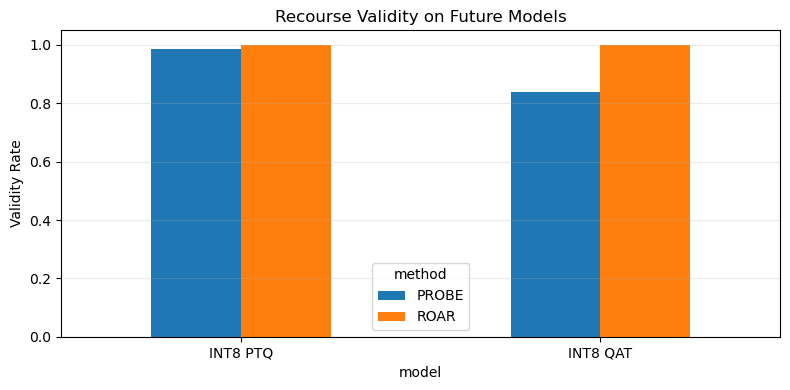

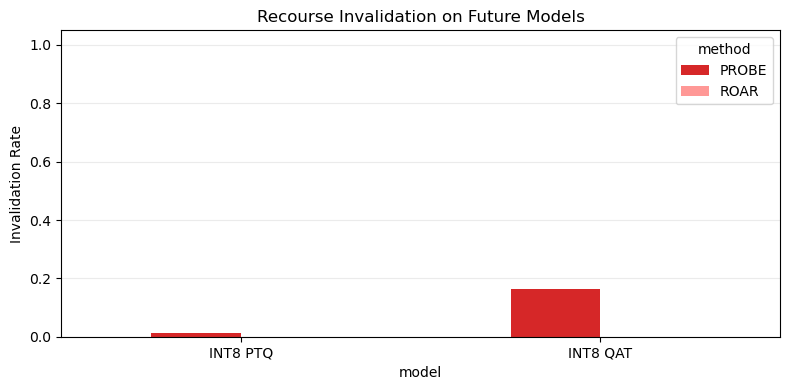

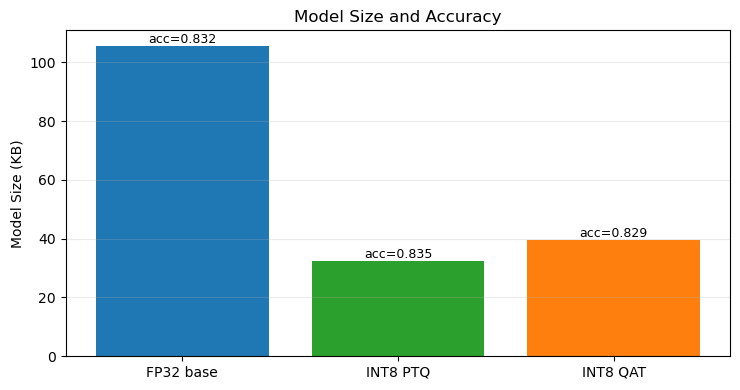

In [19]:
# Final comparison: PROBE vs ROAR transfer + model performance visuals
import matplotlib.pyplot as plt

probe_cmp = recourse_summary.copy()
probe_cmp["method"] = "PROBE"
roar_cmp = roar_recourse_summary.copy()
roar_cmp["method"] = "ROAR"

comparison_df = pd.concat([probe_cmp, roar_cmp], ignore_index=True)
comparison_df["recourse_invalidation_rate"] = comparison_df["recourse_invalidation_rate"].fillna(
    1.0 - comparison_df["recourse_validity_rate"]
)

print("Combined transfer comparison table")
display(
    comparison_df[[
        "method",
        "model",
        "recourse_validity_rate",
        "recourse_invalidation_rate",
        "delta_vs_base",
    ]].sort_values(["method", "model"]).reset_index(drop=True)
 )

# Plot 1: Validity rates by method and future model
future_only = comparison_df[comparison_df["model"] != "FP32 base"].copy()
if len(future_only) > 0:
    pivot_valid = future_only.pivot(index="model", columns="method", values="recourse_validity_rate")
    ax = pivot_valid.plot(kind="bar", figsize=(8, 4), rot=0)
    ax.set_title("Recourse Validity on Future Models")
    ax.set_ylabel("Validity Rate")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

# Plot 2: Invalidation rates by method and future model
if len(future_only) > 0:
    pivot_inv = future_only.pivot(index="model", columns="method", values="recourse_invalidation_rate")
    ax = pivot_inv.plot(kind="bar", figsize=(8, 4), rot=0, color=["#d62728", "#ff9896"])
    ax.set_title("Recourse Invalidation on Future Models")
    ax.set_ylabel("Invalidation Rate")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

# Plot 3: Model compression-performance tradeoff
perf_plot_df = model_table[["model", "test_acc", "size_kb"]].copy()
fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(perf_plot_df["model"], perf_plot_df["size_kb"], color=["#1f77b4", "#2ca02c", "#ff7f0e"][:len(perf_plot_df)])
ax.set_title("Model Size and Accuracy")
ax.set_ylabel("Model Size (KB)")
ax.grid(axis="y", alpha=0.25)

for bar, acc in zip(bars, perf_plot_df["test_acc"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height(),
        f"acc={acc:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

In [20]:
# ===== New Section: Quantized Base (German) -> FP32 Future (German Corrected) =====
GERMAN_BASE_PATH = "data/german.csv"
GERMAN_FUTURE_PATH = "data/german_corrected.csv"
GERMAN_TARGET = "credit_risk"
GERMAN_BRANCH_EPOCHS = 25
GERMAN_QAT_FINETUNE_EPOCHS = 10
GERMAN_REC_N_SAMPLES = 80

def preprocess_german_pair(base_path, future_path, target_col):
    df_base = pd.read_csv(base_path)
    df_future = pd.read_csv(future_path)

    y_base = df_base[target_col].astype(int).copy()
    y_future = df_future[target_col].astype(int).copy()
    X_base_raw = df_base.drop(columns=[target_col]).copy()
    X_future_raw = df_future.drop(columns=[target_col]).copy()

    num_cols = X_base_raw.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_base_raw.select_dtypes(include=["object", "category"]).columns.tolist()

    X_all = pd.concat([X_base_raw, X_future_raw], axis=0).reset_index(drop=True)
    scaler = StandardScaler()
    if len(num_cols) > 0:
        X_all[num_cols] = scaler.fit_transform(X_all[num_cols])
    X_all = pd.get_dummies(X_all, columns=cat_cols, dtype=float).astype(np.float32)

    n_base = len(X_base_raw)
    X_base = X_all.iloc[:n_base].copy()
    X_future = X_all.iloc[n_base:].copy()

    Xb_train, Xb_test, yb_train, yb_test = train_test_split(
        X_base, y_base, test_size=0.20, random_state=SEED, stratify=y_base
    )
    Xf_train, Xf_test, yf_train, yf_test = train_test_split(
        X_future, y_future, test_size=0.20, random_state=SEED, stratify=y_future
    )

    return {
        "Xb_train": Xb_train,
        "Xb_test": Xb_test,
        "yb_train": yb_train,
        "yb_test": yb_test,
        "Xf_train": Xf_train,
        "Xf_test": Xf_test,
        "yf_train": yf_train,
        "yf_test": yf_test,
        "feature_min": Xb_train.min(axis=0).to_numpy(dtype=np.float32),
        "feature_max": Xb_train.max(axis=0).to_numpy(dtype=np.float32),
    }

gpair = preprocess_german_pair(GERMAN_BASE_PATH, GERMAN_FUTURE_PATH, GERMAN_TARGET)

Xb_train_t = torch.tensor(gpair["Xb_train"].to_numpy(), dtype=torch.float32)
yb_train_t = torch.tensor(gpair["yb_train"].to_numpy(), dtype=torch.float32)
Xb_test_t = torch.tensor(gpair["Xb_test"].to_numpy(), dtype=torch.float32)
yb_test_t = torch.tensor(gpair["yb_test"].to_numpy(), dtype=torch.float32)
Xf_train_t = torch.tensor(gpair["Xf_train"].to_numpy(), dtype=torch.float32)
yf_train_t = torch.tensor(gpair["yf_train"].to_numpy(), dtype=torch.float32)
Xf_test_t = torch.tensor(gpair["Xf_test"].to_numpy(), dtype=torch.float32)
yf_test_t = torch.tensor(gpair["yf_test"].to_numpy(), dtype=torch.float32)

german_input_dim = Xb_train_t.shape[1]
gbase_loader = DataLoader(TensorDataset(Xb_train_t, yb_train_t), batch_size=BATCH_SIZE, shuffle=True)
gfuture_loader = DataLoader(TensorDataset(Xf_train_t, yf_train_t), batch_size=BATCH_SIZE, shuffle=True)

print(f"German aligned input_dim: {german_input_dim}")
print(f"Base train/test: {Xb_train_t.shape} / {Xb_test_t.shape}")
print(f"Future train/test: {Xf_train_t.shape} / {Xf_test_t.shape}")

German aligned input_dim: 20
Base train/test: torch.Size([800, 20]) / torch.Size([200, 20])
Future train/test: torch.Size([800, 20]) / torch.Size([200, 20])


In [21]:
# Train old-data FP32 source, quantize to PTQ/QAT base models, and train corrected-data FP32 future
ger_source_fp32 = MLPBinary(input_dim=german_input_dim)
ger_source_fp32 = train_model(
    ger_source_fp32, gbase_loader, Xb_test_t, yb_test_t, epochs=GERMAN_BRANCH_EPOCHS, lr=LR
)

ger_ptq_model = quantize_dynamic(copy.deepcopy(ger_source_fp32).eval(), {nn.Linear}, dtype=torch.qint8)

ger_qat_float = QuantizableMLPBinary(input_dim=german_input_dim)
ger_qat_float.load_state_dict(copy.deepcopy(ger_source_fp32).state_dict(), strict=True)
ger_qat_float.fuse_model()
ger_qat_float.qconfig = get_default_qat_qconfig("fbgemm")
prepare_qat(ger_qat_float, inplace=True)
ger_qat_opt = optim.Adam(ger_qat_float.parameters(), lr=LR * 0.5)
ger_qat_criterion = nn.BCEWithLogitsLoss()
ger_qat_float.train()
for epoch in range(GERMAN_QAT_FINETUNE_EPOCHS):
    for xb, yb in gbase_loader:
        ger_qat_opt.zero_grad()
        logits = ger_qat_float(xb)
        loss = ger_qat_criterion(logits, yb)
        loss.backward()
        ger_qat_opt.step()
ger_qat_float.eval()
ger_qat_model = copy.deepcopy(ger_qat_float)
convert(ger_qat_model, inplace=True)

ger_future_fp32 = MLPBinary(input_dim=german_input_dim)
ger_future_fp32 = train_model(
    ger_future_fp32, gfuture_loader, Xf_test_t, yf_test_t, epochs=GERMAN_BRANCH_EPOCHS, lr=LR
)

ger_eval = nn.BCEWithLogitsLoss()
ger_perf = pd.DataFrame([
    {
        "model": "German base FP32 source",
        "acc": evaluate_model(ger_source_fp32, Xb_test_t, yb_test_t, ger_eval).accuracy,
        "auc": evaluate_model(ger_source_fp32, Xb_test_t, yb_test_t, ger_eval).auroc,
    },
    {
        "model": "German base INT8 PTQ",
        "acc": evaluate_model(ger_ptq_model, Xb_test_t, yb_test_t, ger_eval).accuracy,
        "auc": evaluate_model(ger_ptq_model, Xb_test_t, yb_test_t, ger_eval).auroc,
    },
    {
        "model": "German base INT8 QAT",
        "acc": evaluate_model(ger_qat_model, Xb_test_t, yb_test_t, ger_eval).accuracy,
        "auc": evaluate_model(ger_qat_model, Xb_test_t, yb_test_t, ger_eval).auroc,
    },
    {
        "model": "German future FP32 (corrected)",
        "acc": evaluate_model(ger_future_fp32, Xf_test_t, yf_test_t, ger_eval).accuracy,
        "auc": evaluate_model(ger_future_fp32, Xf_test_t, yf_test_t, ger_eval).auroc,
    },
] )
display(ger_perf)

Epoch  5/25 | val_loss=0.5374 | val_acc=71.00% | val_auc=0.7374
Epoch 10/25 | val_loss=0.5616 | val_acc=69.50% | val_auc=0.7380
Epoch 15/25 | val_loss=0.6738 | val_acc=73.50% | val_auc=0.7194
Epoch 20/25 | val_loss=0.9011 | val_acc=70.50% | val_auc=0.7167
Epoch 25/25 | val_loss=1.1824 | val_acc=72.00% | val_auc=0.7151


C:\Users\hashi\AppData\Local\Temp\ipykernel_32436\1490186796.py:7: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  ger_ptq_model = quantize_dynamic(copy.deepcopy(ger_source_fp32).eval(), {nn.Linear}, dtype=torch.qint8)
C:\Users\hashi\AppData\Local\Temp\ipykernel_32436\1490186796.py:13: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
Fo

Epoch  5/25 | val_loss=0.4642 | val_acc=80.00% | val_auc=0.8283
Epoch 10/25 | val_loss=0.4836 | val_acc=75.50% | val_auc=0.8069
Epoch 15/25 | val_loss=0.5356 | val_acc=76.00% | val_auc=0.7885
Epoch 20/25 | val_loss=0.6305 | val_acc=75.50% | val_auc=0.7885
Epoch 25/25 | val_loss=0.7324 | val_acc=71.50% | val_auc=0.7817


,model,acc,auc
0,German base FP32 source,0.720,0.715119
1,German base INT8 PTQ,0.700,0.714405
2,German base INT8 QAT,0.705,0.716071
3,German future FP32 (corrected),0.715,0.781667


In [22]:
# Simple Wachter-style CF search for quantized-base models (L1 nearest), with gradient surrogate
def _sigmoid_prob(model, x_np):
    xt = torch.tensor(x_np, dtype=torch.float32).reshape(1, -1)
    with torch.no_grad():
        return torch.sigmoid(model(xt)).item()

def wachter_cf_quantized_base(
    quant_model,
    surrogate_model,
    x0_np,
    feature_min,
    feature_max,
    lr=0.03,
    lambda_param=0.02,
    n_iter=800,
    threshold=0.5,
 ):
    surrogate_model.eval()
    quant_model.eval()

    x0 = torch.tensor(x0_np, dtype=torch.float32).reshape(1, -1)
    xmin = torch.tensor(feature_min, dtype=torch.float32).reshape(1, -1)
    xmax = torch.tensor(feature_max, dtype=torch.float32).reshape(1, -1)
    x_cf = x0.clone().detach().requires_grad_(True)
    opt = optim.Adam([x_cf], lr=lr)
    target = torch.ones(1, dtype=torch.float32)

    best = None
    best_cost = float("inf")
    best_quant_prob = 0.0

    for _ in range(n_iter):
        opt.zero_grad()
        # Gradient objective on differentiable surrogate model
        p_sur = torch.sigmoid(surrogate_model(x_cf))
        clf_loss = nn.BCELoss()(p_sur, target)
        l1 = torch.norm(x_cf - x0, p=1)
        loss = clf_loss + lambda_param * l1
        loss.backward()
        opt.step()

        with torch.no_grad():
            x_cf.clamp_(xmin, xmax)
            p_quant = torch.sigmoid(quant_model(x_cf)).item()
            if p_quant >= threshold:
                cost = torch.norm(x_cf - x0, p=1).item()
                if cost < best_cost:
                    best_cost = cost
                    best = x_cf.detach().clone()
                    best_quant_prob = p_quant

    if best is None:
        best = x_cf.detach().clone()
        best_quant_prob = torch.sigmoid(quant_model(best)).item()

    out = best.cpu().numpy().reshape(-1)
    meta = {
        "quant_prob_cf": float(best_quant_prob),
        "l1_cost": float(np.linalg.norm(out - x0_np, ord=1)),
    }
    return out, meta

def run_quantized_base_generation(quant_model, surrogate_model, X_test_df, n_samples, tag):
    with torch.no_grad():
        probs = torch.sigmoid(quant_model(torch.tensor(X_test_df.to_numpy(), dtype=torch.float32))).numpy()
    neg_idx = np.where(probs < DECISION_THRESHOLD)[0]
    chosen = neg_idx[: min(n_samples, len(neg_idx))]

    rows = []
    for idx in chosen:
        x0 = X_test_df.iloc[idx].to_numpy(dtype=np.float32)
        x_cf, meta = wachter_cf_quantized_base(
            quant_model,
            surrogate_model,
            x0,
            gpair["feature_min"],
            gpair["feature_max"],
            lr=0.03,
            lambda_param=0.02,
            n_iter=800,
            threshold=DECISION_THRESHOLD,
        )
        rows.append({
            "method": tag,
            "idx": int(idx),
            "x0": x0,
            "xcf": x_cf,
            "base_quant_prob_cf": meta["quant_prob_cf"],
            "l1_cost": meta["l1_cost"],
            "base_quant_valid": float(meta["quant_prob_cf"] >= DECISION_THRESHOLD),
        })
    return rows

ptq_generated_german = run_quantized_base_generation(
    ger_ptq_model, ger_source_fp32, gpair["Xb_test"], GERMAN_REC_N_SAMPLES, "PTQ->FP32_future"
)
qat_generated_german = run_quantized_base_generation(
    ger_qat_model, ger_qat_float, gpair["Xb_test"], GERMAN_REC_N_SAMPLES, "QAT->FP32_future"
)

print(f"German PTQ CF generated: {len(ptq_generated_german)}")
print(f"German QAT CF generated: {len(qat_generated_german)}")

German PTQ CF generated: 60
German QAT CF generated: 59


In [23]:
# Evaluate quantized-base generated CFs on future FP32 corrected model
def evaluate_generated_on_future(generated_rows, future_model):
    out = []
    for item in generated_rows:
        xcf = item["xcf"]
        with torch.no_grad():
            p_future = torch.sigmoid(future_model(torch.tensor(xcf, dtype=torch.float32).reshape(1, -1))).item()
        rec = {**item}
        rec["future_fp32_prob_cf"] = p_future
        rec["future_fp32_valid"] = float(p_future >= DECISION_THRESHOLD)
        rec["invalid_on_future"] = float((item["base_quant_valid"] == 1.0) and (p_future < DECISION_THRESHOLD))
        rec["prob_shift_future_minus_base"] = p_future - item["base_quant_prob_cf"]
        out.append(rec)
    return pd.DataFrame(out)

ptq_future_eval_df = evaluate_generated_on_future(ptq_generated_german, ger_future_fp32)
qat_future_eval_df = evaluate_generated_on_future(qat_generated_german, ger_future_fp32)
german_transfer_df = pd.concat([ptq_future_eval_df, qat_future_eval_df], ignore_index=True)

summary_rows = []
for tag, sub in german_transfer_df.groupby("method"):
    summary_rows.append(
        {
            "method": tag,
            "n_generated": len(sub),
            "base_quant_valid_rate": sub["base_quant_valid"].mean(),
            "future_fp32_valid_rate": sub["future_fp32_valid"].mean(),
            "future_invalidation_rate": 1.0 - sub["future_fp32_valid"].mean(),
            "invalid_on_future_rate": sub["invalid_on_future"].mean(),
            "mean_l1_cost": sub["l1_cost"].mean(),
            "mean_prob_shift": sub["prob_shift_future_minus_base"].mean(),
        }
    )

german_transfer_summary = pd.DataFrame(summary_rows)
print("German cross-dataset transfer summary: quantized base -> FP32 future")
display(german_transfer_summary)

print("Invalid-on-future examples (valid on quantized base but invalid on future FP32):")
display(
    german_transfer_df[german_transfer_df["invalid_on_future"] == 1.0][
        ["method", "idx", "base_quant_prob_cf", "future_fp32_prob_cf", "l1_cost", "prob_shift_future_minus_base"]
    ].head(20)
)

German cross-dataset transfer summary: quantized base -> FP32 future


,method,n_generated,base_quant_valid_rate,future_fp32_valid_rate,future_invalidation_rate,invalid_on_future_rate,mean_l1_cost,mean_prob_shift
0,PTQ->FP32_future,60,1.000000,0.950000,0.050000,0.050000,2.267728,0.185883
1,QAT->FP32_future,59,0.983051,0.949153,0.050847,0.050847,2.907153,0.122440


Invalid-on-future examples (valid on quantized base but invalid on future FP32):


,method,idx,base_quant_prob_cf,future_fp32_prob_cf,l1_cost,prob_shift_future_minus_base
42,PTQ->FP32_future,158,0.995510,0.068160,0.873448,-0.927350
50,PTQ->FP32_future,175,0.993425,0.111685,3.466104,-0.881740
53,PTQ->FP32_future,179,0.994012,0.001080,2.952101,-0.992932
101,QAT->FP32_future,158,0.605164,0.297705,0.838284,-0.307458
108,QAT->FP32_future,175,0.605164,0.311219,3.799581,-0.293945
111,QAT->FP32_future,179,0.999805,0.001054,3.995671,-0.998750


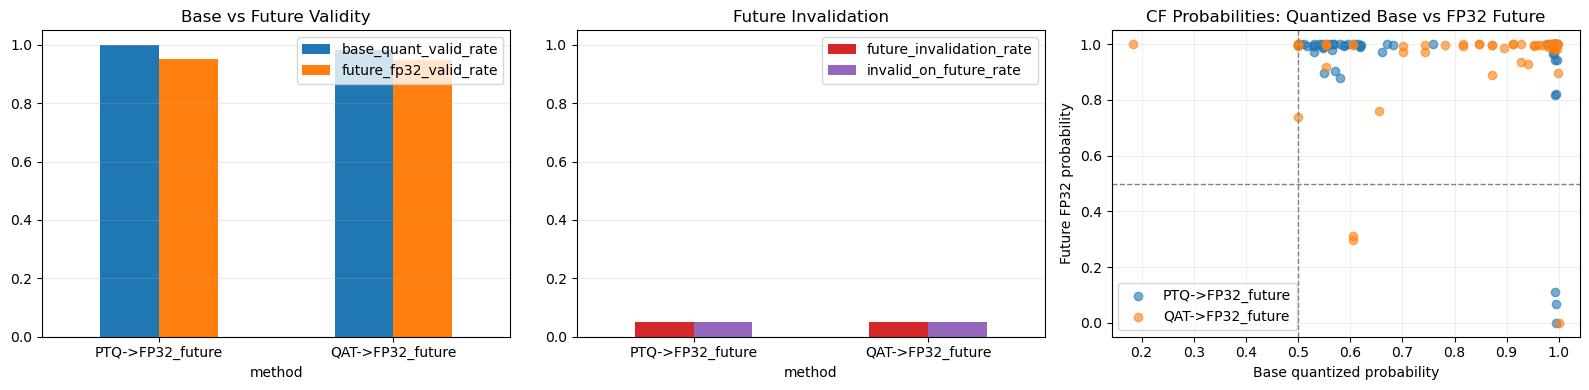

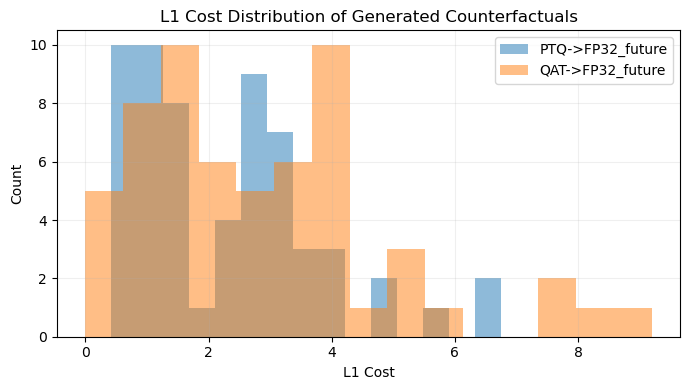

In [24]:
# Visualize PTQ vs QAT transfer under the German cross-dataset setup
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

plot_df = german_transfer_summary.set_index("method")
plot_df[["base_quant_valid_rate", "future_fp32_valid_rate"]].plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Base vs Future Validity")
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis="y", alpha=0.25)

plot_df[["future_invalidation_rate", "invalid_on_future_rate"]].plot(kind="bar", ax=axes[1], rot=0, color=["#d62728", "#9467bd"])
axes[1].set_title("Future Invalidation")
axes[1].set_ylim(0, 1.05)
axes[1].grid(axis="y", alpha=0.25)

for method_name, sub in german_transfer_df.groupby("method"):
    axes[2].scatter(
        sub["base_quant_prob_cf"],
        sub["future_fp32_prob_cf"],
        alpha=0.6,
        label=method_name,
    )
axes[2].axvline(DECISION_THRESHOLD, linestyle="--", color="gray", linewidth=1)
axes[2].axhline(DECISION_THRESHOLD, linestyle="--", color="gray", linewidth=1)
axes[2].set_title("CF Probabilities: Quantized Base vs FP32 Future")
axes[2].set_xlabel("Base quantized probability")
axes[2].set_ylabel("Future FP32 probability")
axes[2].legend()
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
for method_name, sub in german_transfer_df.groupby("method"):
    plt.hist(sub["l1_cost"], bins=15, alpha=0.5, label=method_name)
plt.title("L1 Cost Distribution of Generated Counterfactuals")
plt.xlabel("L1 Cost")
plt.ylabel("Count")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()